# Regression
Linear Regression

In [ ]:
pip install scikit-learn

[50]- 1D - unclear
[[50]] - 2D - 1 sample, 1 feature - proper row in table
[[50],[60]] - 2 sample. 1 feature

outer[] = rows[samples]
inner [] = column [features]

fit() and predict() = allow only 2D so even its single value provide 2 bracket

In [12]:
from sklearn.linear_model import LinearRegression
import numpy as np

#data
x = np.array([22,41,58]).reshape(-1,1)
y = np.array([23000,80000,150000])

#model
model = LinearRegression()
model.fit(x,y)

#prediction
print (model.predict([[50]])) 


[118335.56012333]


Decision Tree

In [21]:
from sklearn.tree import DecisionTreeRegressor
import numpy as np

#data
x = np.array([22,41,58]).reshape(-1,1)
y = np.array([23000,80000,150000])

#model
model = DecisionTreeRegressor()
model.fit(x,y)

#prediction
print(model.predict([[35]]))

[80000.]


Random Forest

In [40]:
from sklearn.ensemble import RandomForestRegressor
import numpy as np
np.random.seed(42)
#data
x= np.array([22,41,58]).reshape(-1,1)
y = np.array([23000,80000,150000])

#model
model = RandomForestRegressor(n_estimators=50)
model.fit(x,y)

#prediction
print(model.predict([[50]]))


[118580.]


Ada Boosting

Ada boosting cannot  work alone. it needs base model(decision tree)
-its not a model itself, it is a method to combine models

In [49]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor

x = [[1],[2],[3],[4]]
y = [2,4,6,9]

#create model 
model = AdaBoostRegressor( estimator= DecisionTreeRegressor(max_depth= 1), n_estimators= 5 )

#Train
model.fit(x,y)

#predict
print (model.predict([[5]]))

print(model.estimator_weights_)




[6.]
[0.25131443 0.20010899 0.55765538 0.40689978 0.02182715]


In [9]:


#create model 
model = AdaBoostRegressor( estimator= DecisionTreeRegressor(max_depth= 1), n_estimators= 5 )

model.fit(x,y)
print(model.estimator_weights_)

[0.33647224 0.         0.         0.         0.        ]


x   y
22  23k
41  80k
58  150k
Step 1: Decision tree
x<= 41 | x> 41

Group 1 = 23000+80000 /2 = 51500
group 2 = 150000
prdiction for x=50
x>41 -> it goes right
prediction = 150000

step 2:
focus on error
adjuct predictions downward

final step :

m1 - 150000 - rough 
m2 - 120000 - fis mistak
m3 - 100000
m4 - 130000


Final = weight avaerage/ correction


In [53]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
import numpy as np

#data
x= np.array([[22],[41],[58]]) 
#.reshape(-1,1)
y = np.array([23000,80000,150000]) 

#create model 
model = AdaBoostRegressor( estimator= DecisionTreeRegressor(max_depth= 1), n_estimators= 5 )

#Train
model.fit(x,y)

#predict
print (model.predict([[50]]))

print(model.estimator_weights_)

print(model.estimator_errors_)

[150000.]
[0.69314718 1.09861229 0.69314718 1.94591015 0.91629073]
[0.33333333 0.25       0.33333333 0.125      0.28571429]


#Gradient Boost 

In [58]:
from sklearn.ensemble import GradientBoostingRegressor
import numpy as np

#data
x= np.array([[22],[41],[58]]) 
#.reshape(-1,1)
y = np.array([23000,80000,150000]) 

#create model 
model = GradientBoostingRegressor()

# We dont want specifically use decision tree it will work by manually

#Train
model.fit(x,y)

#predict
print (model.predict([[50]]))


[149998.25580147]


# Classification Algorithm:

Logistic Algorithm: To predict category , we cant find the salary 
this is useful for yes or no / spam or not


In [ ]:
from sklearn.linear_model import LogisticRegression
import numpy as np

#data
x= np.array([[22],[41],[58]]) 
#.reshape(-1,1)
y = np.array([0,1,1]) # 0- low salary 1= high salary

model = LogisticRegression()
model.fit(x,y)

print(model.predict([[41]]))

print(model.predict_proba([[50]]))

[1]


In [81]:
from sklearn.linear_model import LogisticRegression
import numpy as np
import matplotlib.pyplot as plt

#data
x= np.array([[22],[41],[58]]) 
#.reshape(-1,1)
y = np.array([0,0,1]) # 0- low salary 1= high salary

model = LogisticRegression()
model.fit(x,y)

print(model.predict([[50]]))






[1]


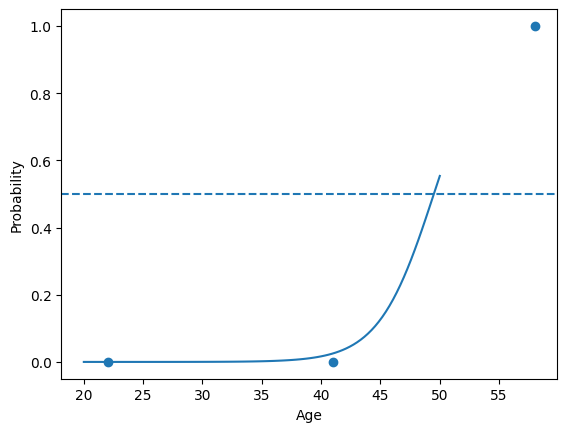

In [82]:
#create curve
X_test = np.linspace(20,50,100).reshape(-1,1)
y_prob = model.predict_proba(X_test)[:,1]

plt.scatter(x,y) # data point
plt.plot(X_test,y_prob) # sigmoid curve

plt.axhline(0.5,linestyle = '--') # decision boundry 

plt.xlabel("Age")
plt.ylabel("Probability")
plt.show()

SVM Algorithm:

In [79]:
from sklearn.svm import SVC
import numpy as np

X = np.array([[2,3],[3,4],[5,6],[6,7]])
y = np.array([0,0,1,1])

model= SVC(kernel= 'linear')
model.fit(X,y)

print(model.predict([[1,5]]))



# checking where it fall left side =0 , right side =1 

[0]


KNN Algoritham

k-Nearest Neigbors

*find nearest and take majority

In [87]:
from sklearn.neighbors import KNeighborsClassifier
import numpy as np

X = np.array([[2,3],[3,4],[5,6],[6,7]])
y = np.array([0,0,1,1])

model = KNeighborsClassifier(n_neighbors=3)
model.fit(X,y)
print(model.predict([[96,97]]))

[1]


# Unsupervised learning
 K-Mean Algorithm


In [90]:
from sklearn.cluster import KMeans
import numpy as np

X= np.array([[1,2],[2,3],[8,9],[9,10]])

model = KMeans(n_clusters=2)
model.fit(X)

print(model.labels_) # cluster assigned
print (model.cluster_centers_) # centroids

[1 1 0 0]
[[8.5 9.5]
 [1.5 2.5]]


Collaborative filtering

In [91]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

#user-item matrix
data = np.array ([[5,4,0],
                [5,4,4],
                [0,0,5]
])

simiarity = cosine_similarity(data)
print(simiarity)

[[1.         0.84811452 0.        ]
 [0.84811452 1.         0.52981294]
 [0.         0.52981294 1.        ]]
